# Resilience study — figures and tables (with source)

This notebook reproduces every table and figure from the resilience report
(`all_results.tex`). Each figure cell contains the **actual plotting code**, rendered
inline. All resilience numbers use the **MILP cost-optimal flow** unless a weight grid is
shown.

> **Data-integrity note.** The published `tab:worst` (corrected) and `tab:res` tables
> pooled MILP **and** ASP rows from `resource_resilience.csv`. These metrics depend on
> the flow, so the ASP rows do not belong under a "cost-optimal (MILP) flow" caption.
> This notebook uses the **MILP-only** values throughout (e.g. small `R_res` 0.047 here
> vs 0.073 published).

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path

# Anchor on the actual results CSV so paths resolve wherever the kernel started.
TARGET = Path("src/multibatch/experiments/milp_resilience/results/suite_consolidated.csv")
ROOT = next((c for c in [Path.cwd(), *Path.cwd().parents] if (c / TARGET).exists()), None)
assert ROOT is not None, f"could not locate {TARGET} above {Path.cwd()}"
os.chdir(ROOT); sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from IPython.display import display

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# ---- shared publication style (mirrors experiments/.../style.py) ----
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "font.family": "serif", "mathtext.fontset": "cm",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "axes.titlesize": 10.5, "axes.labelsize": 10,
})
CFG_COLOR = {"baseline": "#999999", "hetero_w8": "#009E73",
             "conc_w8": "#0072B2", "full_w8_8": "#D55E00"}
CFG_LABEL = {"baseline": "baseline", "hetero_w8": "hetero",
             "conc_w8": "conc", "full_w8_8": "full"}
CFG_ORDER = ["baseline", "hetero_w8", "conc_w8", "full_w8_8"]
SOLVER_COLOR = {"milp": "#0072B2", "asp": "#E69F00"}
C = CFG_COLOR; CONFIG_COLOR = CFG_COLOR; CONFIG_ORDER = CFG_ORDER   # aliases used by figure code
NET_MARK = {0.0: "o", 4.0: "*"}
NET_LABEL = {0.0: r"$w_{net}=0$", 4.0: r"$w_{net}=4\lambda$ (network lever)"}
MARKERS = {"baseline": "o", "hetero_w8": "s", "conc_w8": "D", "full_w8_8": "^"}

def short(name):
    return ("industry" if name.startswith("industry")
            else name.replace("layered_", "").replace("_seed", " s"))
def inst_order(insts):
    return sorted(insts, key=lambda s: (not s.startswith("industry"), s))
def _wtag(wn, wf):
    f = lambda v: "0" if v == 0 else f"{int(v)}"
    return f"{f(wn)}/{f(wf)}"

# saving is replaced by inline display
def save(fig, name): plt.show()
_save = save

# ---- data ----
RES = Path("src/multibatch/experiments/milp_resilience/results")
df   = pd.read_csv(RES / "suite_consolidated.csv")
rr   = pd.read_csv(RES / "resource_resilience.csv")
dose = pd.read_csv(RES / "suite_industry_doseB.csv")
sp   = pd.read_csv(RES / "strategy_probe.csv")
rr_milp = rr[rr.solver == "milp"].copy()        # MILP-only -> no ASP contamination

def size_of(i):
    return ("industrial" if i.startswith("industry") else "medium" if "medium" in i else "small")
df["size"] = df["instance"].map(size_of)
rr["size"] = rr["instance"].map(size_of)
SIZES = ["small", "medium", "industrial"]
CFG = CFG_ORDER
OPT = df[(df.flow_solver == "milp") & (df.lambda_net == 0) & (df.lambda_flow == 0)].copy()

# prepped frames for the lever / tradeoff figures
def _prep_milp(d):
    d = d[d.flow_solver == "milp"].copy()
    d["grp"] = np.where(d.instance.str.startswith("industry"), "industry",
                        np.where(d.instance.str.contains("medium"), "medium", "small"))
    opt = d[(d.lambda_net == 0) & (d.lambda_flow == 0)].groupby("instance").flow_cost.first()
    d["cost_rise"] = (d.flow_cost / d.instance.map(opt) - 1) * 100
    return d
DLEV = _prep_milp(df)
DTD  = df[df.flow_solver == "milp"].copy()       # already has the "size" column
print(len(df), "rows;", df.instance.nunique(), "instances")

repo root: /Users/racqueldennison/Documents/Masters/realdeal_masters/combined_encodings
336 rows; 11 instances


## Tables

### Table 1 — Instance set (`tab:inst`)

In [2]:
pd.DataFrame(
    [["small", 5, "small", 2, "2 active", "ASP, MILP"],
     ["medium", 5, "medium", 3, "2 active", "ASP, MILP"],
     ["industrial", 1, "50", 35, "16 (6 active)", "MILP"]],
    columns=["Size", "Seeds", "Locations", "Products", "Transport resources", "Solvers"],
).set_index("Size")

,Seeds,Locations,Products,Transport resources,Solvers
Size,,,,,
small,5,small,2,2 active,"ASP, MILP"
medium,5,medium,3,2 active,"ASP, MILP"
industrial,1,50,35,16 (6 active),MILP


### Table 2 — Mean single-trip resilience, baseline vs `conc_w8` (`tab:single`)

In [3]:
recs = []
for size in SIZES:
    for solver in ["asp", "milp"]:
        ss = df[(df.flow_solver == solver) & (df.lambda_net == 0) & (df.lambda_flow == 0)
                & (df["size"] == size)]
        if ss.empty:
            continue
        row = {"size": size, "solver": solver.upper()}
        for cfg in ["baseline", "conc_w8"]:
            g = ss[ss.config == cfg][["nri", "nri_worst", "cov_cvar10"]].mean()
            row[(cfg, "NRI")] = g["nri"]; row[(cfg, "NRI_worst")] = g["nri_worst"]
            row[(cfg, "CVaR10")] = g["cov_cvar10"]
        recs.append(row)
t = pd.DataFrame(recs).set_index(["size", "solver"])
t.columns = pd.MultiIndex.from_tuples(t.columns)
t.round(4)

baseline                  conc_w8                 
                       NRI NRI_worst CVaR10     NRI NRI_worst CVaR10
size       solver                                                   
small      ASP      0.9331    0.9000 0.8419  0.9485    0.9000 0.8584
           MILP     0.9331    0.9000 0.8411  0.9459    0.9000 0.8489
medium     ASP      0.9481    0.9178 0.8099  0.9542    0.9178 0.8264
           MILP     0.9406    0.9133 0.7964  0.9456    0.9178 0.8208
industrial MILP     0.9819    0.8912 0.8022  0.9851    0.9164 0.8384

### Table 3 — Win-rate of each packing config vs baseline (`tab:wins`)

In [4]:
METRICS = {"NRI": "nri", "CVaR10": "cov_cvar10", "NRI_worst": "nri_worst"}
recs = []
for solver in ["MILP", "ASP"]:
    s = df[(df.flow_solver == solver.lower()) & (df.lambda_net == 0) & (df.lambda_flow == 0)]
    for mlab, col in METRICS.items():
        piv = s.pivot_table(index="instance", columns="config", values=col)
        row = {"solver": solver, "metric": mlab}
        for cfg in ["hetero_w8", "conc_w8", "full_w8_8"]:
            row[cfg] = f"{int((piv[cfg] > piv['baseline'] + 1e-9).sum())}/{len(piv)}"
        recs.append(row)
pd.DataFrame(recs).set_index(["solver", "metric"])

hetero_w8 conc_w8 full_w8_8
solver metric                               
MILP   NRI            4/11   10/11     10/11
       CVaR10         9/11    8/11      7/11
       NRI_worst      3/11    4/11      3/11
ASP    NRI            0/10   10/10      9/10
       CVaR10         8/10    7/10      9/10
       NRI_worst      2/10    1/10      3/10

### Table 4 — Mean metric values, all four configs (`tab:means`)

In [5]:
recs = []
for solver in ["MILP", "ASP"]:
    s = df[(df.flow_solver == solver.lower()) & (df.lambda_net == 0) & (df.lambda_flow == 0)]
    for mlab, col in METRICS.items():
        piv = s.pivot_table(index="instance", columns="config", values=col)
        row = {"solver": solver, "metric": mlab}
        for cfg in CFG:
            row[cfg] = piv[cfg].mean()
        recs.append(row)
pd.DataFrame(recs).set_index(["solver", "metric"]).round(4)

baseline  hetero_w8  conc_w8  full_w8_8
solver metric                                            
MILP   NRI          0.9409     0.9418   0.9493     0.9465
       CVaR10       0.8172     0.8338   0.8352     0.8344
       NRI_worst    0.9053     0.9078   0.9096     0.9067
ASP    NRI          0.9406     0.9406   0.9513     0.9471
       CVaR10       0.8259     0.8371   0.8424     0.8459
       NRI_worst    0.9089     0.9117   0.9089     0.9117

### Table 5 — Arc-level worst case $R_{TR}$ by weight grid (`tab:worst`, MILP)

In [6]:
d = df[df.flow_solver == "milp"].drop_duplicates(["instance", "lambda_net", "lambda_flow"])
recs = []
for size in SIZES:
    ss = d[d["size"] == size]
    for wn, wf in [(0, 0), (0, 4), (0, 8), (4, 0)]:
        g = ss[(ss.lambda_net == wn) & (ss.lambda_flow == wf)]
        if g.empty:
            continue
        recs.append({"size": size, "w_net": wn, "w_flow": wf,
                     "min": g.r_tr.min(), "mean": g.r_tr.mean(), "max": g.r_tr.max(),
                     "single_trip_arcs": g.n_single_trip_arcs.mean()})
pd.DataFrame(recs).set_index(["size", "w_net", "w_flow"]).round(3)

min   mean    max  single_trip_arcs
size       w_net w_flow                                       
small      0     0      0.1670 0.3470 0.4670            1.4000
                 4      0.1670 0.3200 0.5000            0.0000
                 8      0.1670 0.3530 0.6000            0.0000
           4     0      0.6670 0.6670 0.6670            2.0000
medium     0     0      0.2000 0.3930 0.5330            2.4000
                 4      0.2000 0.3930 0.5330            0.0000
                 8      0.2000 0.4070 0.5670            0.0000
           4     0      0.3000 0.5930 0.6670            3.2000
industrial 0     0      0.0000 0.0000 0.0000           17.0000
                 4      0.0000 0.0000 0.0000            2.0000
                 8      0.0000 0.0000 0.0000            5.0000
           4     0      0.0000 0.0000 0.0000           76.0000

### Table 6 — Single-mode parametric $\mathrm{CVaR}_\alpha$, heaviest removal (`tab:param`)

In [7]:
alphas = [0.2, 0.4, 0.6, 0.8]
recs = []
for grp, mask in [("industrial", OPT["size"] == "industrial"),
                  ("layered", OPT["size"] != "industrial")]:
    for cfg in ["baseline", "conc_w8"]:
        g = OPT[mask & (OPT.config == cfg)]
        row = {"group": grp, "config": cfg}
        for a in alphas:
            row[f"alpha={a}"] = g[f"cvar_alpha_single_{a}"].mean()
        recs.append(row)
pd.DataFrame(recs).set_index(["group", "config"]).round(4)

alpha=0.2  alpha=0.4  alpha=0.6  alpha=0.8
group      config                                              
industrial baseline     0.8357     0.8432     0.8772     0.8914
           conc_w8      0.8379     0.8549     0.8785     0.9027
layered    baseline     0.5967     0.6844     0.7733     0.8667
           conc_w8      0.5761     0.6356     0.7261     0.8367

### Table 7 — Network-level resilience (`tab:res`, MILP only)

In [8]:
d = rr[(rr.solver == "milp") & (rr.w_net == 0) & (rr.w_flow == 0)]
t = (d.groupby("size")[["r_resource", "nri_resource", "cvar_resource", "n_resources"]]
       .mean().reindex(SIZES).round(3))
t.columns = ["R_res (worst)", "NRI_res (expected)", "CVaR_res (tail)", "Active resources"]
t

,R_res (worst),NRI_res (expected),CVaR_res (tail),Active resources
size,,,,
small,0.0470,0.3750,0.0800,2.0000
medium,0.0530,0.4380,0.1160,2.0000
industrial,0.0000,0.7810,0.4830,6.0000


## Figures

Each cell holds the plotting function source and a call that renders it inline.

### Report figures

**Fig 1** — Single-trip resilience by instance (NRI top, CVaR$_{10}$ bottom).

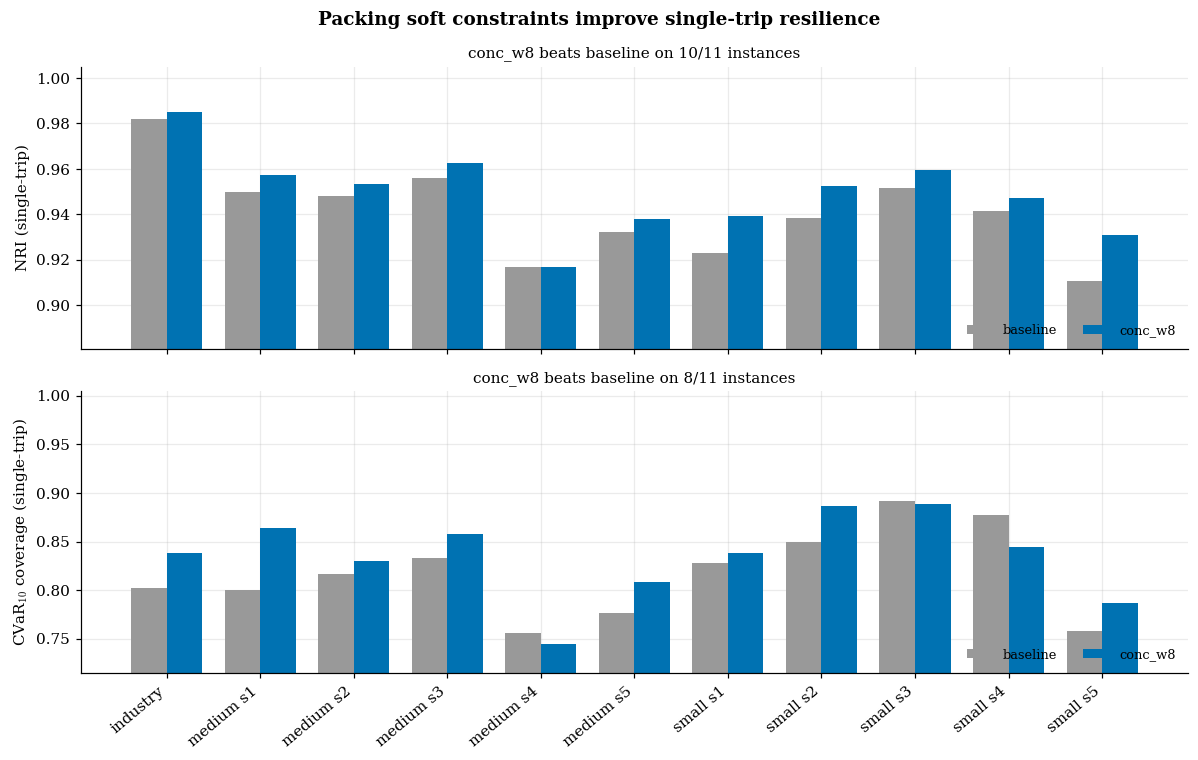

In [9]:
def fig1_packing_effect(df):
    """Single-trip resilience: baseline vs conc_w8 across instances (milp, flow=(0,0))."""
    d = df[(df.flow_solver == "milp") & (df.w_net == 0) & (df.w_flow == 0)]
    piv_n = d.pivot_table(index="instance", columns="config", values="nri")
    piv_c = d.pivot_table(index="instance", columns="config", values="cov_cvar10")
    insts = sorted(piv_n.index, key=lambda s: (not s.startswith("industry"), s))
    x = np.arange(len(insts)); w = 0.38
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for ax, piv, lab in [(axes[0], piv_n, "NRI (single-trip)"),
                         (axes[1], piv_c, "CVaR$_{10}$ coverage (single-trip)")]:
        b = [piv.loc[i, "baseline"] for i in insts]
        c = [piv.loc[i, "conc_w8"] for i in insts]
        ax.bar(x - w/2, b, w, label="baseline", color=C["baseline"])
        ax.bar(x + w/2, c, w, label="conc_w8", color=C["conc_w8"])
        wins = sum(ci > bi + 1e-9 for bi, ci in zip(b, c))
        ax.set_ylabel(lab)
        ax.set_title(f"conc_w8 beats baseline on {wins}/{len(insts)} instances", fontsize=10)
        ax.legend(loc="lower right", ncol=2)
        ax.set_ylim(min(min(b), min(c)) - 0.03, 1.005)
    axes[1].set_xticks(x); axes[1].set_xticklabels([short(i) for i in insts], rotation=40, ha="right")
    fig.suptitle("Packing soft constraints improve single-trip resilience", fontweight="bold")
    fig.tight_layout(); save(fig, "fig1_packing_single_trip")

fig1_packing_effect(df)

**Fig 2** — Flow solve time, MILP vs ASP (log scale).

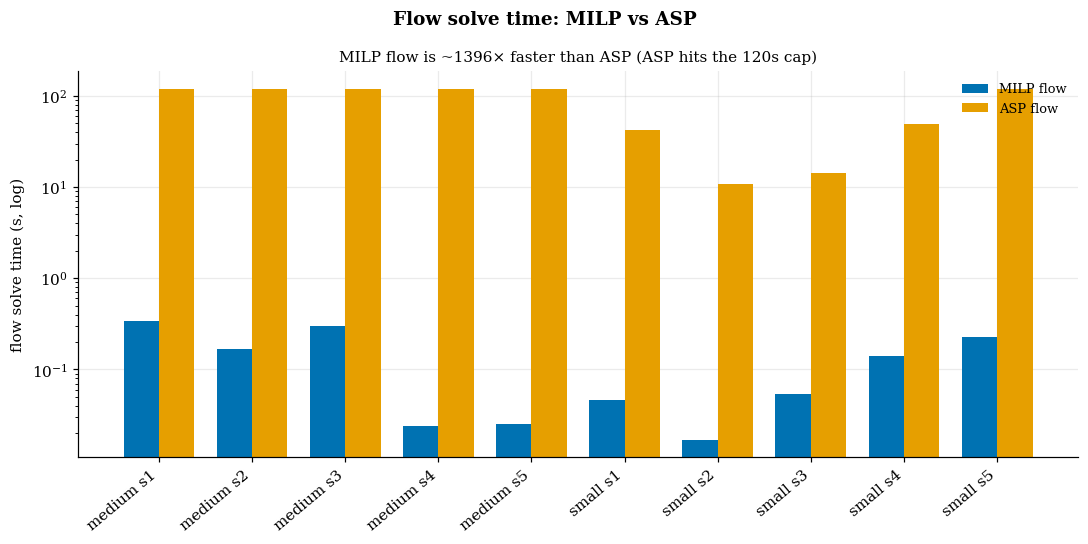

In [10]:
def fig2_asp_vs_milp(df):
    """Flow solve time: ASP vs MILP (layered; industry is MILP-only)."""
    d = df[(df.w_net == 0) & (df.w_flow == 0)].drop_duplicates(["instance", "flow_solver"])
    piv = d.pivot_table(index="instance", columns="flow_solver", values="s1_time")
    piv = piv.dropna(subset=["asp", "milp"], how="any")
    insts = sorted(piv.index)
    x = np.arange(len(insts)); w = 0.38
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, piv["milp"], w, label="MILP flow", color=SOLVER_COLOR["milp"])
    ax.bar(x + w/2, piv["asp"], w, label="ASP flow", color=SOLVER_COLOR["asp"])
    ax.set_yscale("log"); ax.set_ylabel("flow solve time (s, log)")
    sp = (piv["asp"] / piv["milp"]).mean()
    ax.set_title(f"MILP flow is ~{sp:.0f}× faster than ASP (ASP hits the 120s cap)", fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels([short(i) for i in insts], rotation=40, ha="right")
    ax.legend()
    fig.suptitle("Flow solve time: MILP vs ASP", fontweight="bold")
    fig.tight_layout(); save(fig, "fig2_asp_vs_milp")

fig2_asp_vs_milp(df)

**Fig 3** — Industrial: tail and worst-case resilience vs the redundancy weight, with flow cost.

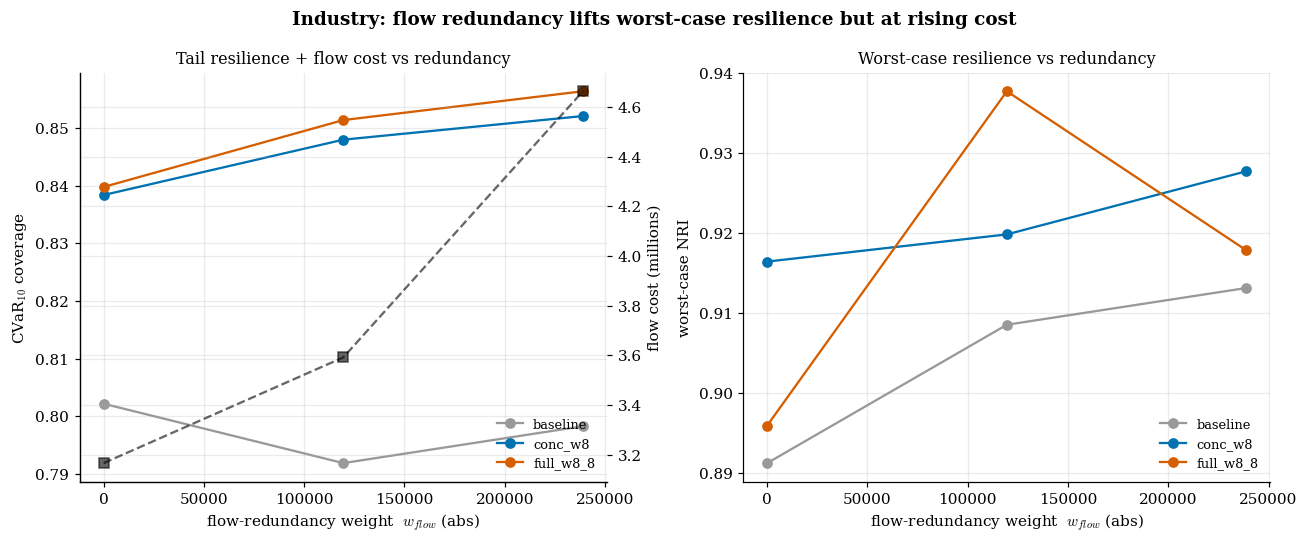

In [11]:
def fig3_flow_lever_tradeoff(df):
    """Industry: cost vs resilience as flow-redundancy (w_flow) rises, per packing."""
    d = df[(df.instance == "industry_test_1") & (df.w_net == 0)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for cfg in ["baseline", "conc_w8", "full_w8_8"]:
        s = d[d.config == cfg].sort_values("w_flow")
        axes[0].plot(s.w_flow, s.cov_cvar10, "o-", color=C[cfg], label=cfg)
        axes[1].plot(s.w_flow, s.nri_worst, "o-", color=C[cfg], label=cfg)
    # cost annotation (flow_cost is per flow point, shared across configs)
    fc = d.drop_duplicates("w_flow").sort_values("w_flow")
    ax2 = axes[0].twinx()
    ax2.plot(fc.w_flow, fc.flow_cost / 1e6, "k--s", alpha=0.6, label="flow cost")
    ax2.set_ylabel("flow cost (millions)")
    for ax, lab in [(axes[0], "CVaR$_{10}$ coverage"), (axes[1], "worst-case NRI")]:
        ax.set_xlabel("flow-redundancy weight  $w_{flow}$ (abs)"); ax.set_ylabel(lab); ax.legend(loc="lower right")
    axes[0].set_title("Tail resilience + flow cost vs redundancy")
    axes[1].set_title("Worst-case resilience vs redundancy")
    fig.suptitle("Industry: flow redundancy lifts worst-case resilience but at rising cost",
                 fontweight="bold")
    fig.tight_layout(); save(fig, "fig3_flow_lever_tradeoff")

fig3_flow_lever_tradeoff(df)

**Fig 4** — Network-level resilience vs arc-level $R_{TR}$ (MILP-only input).

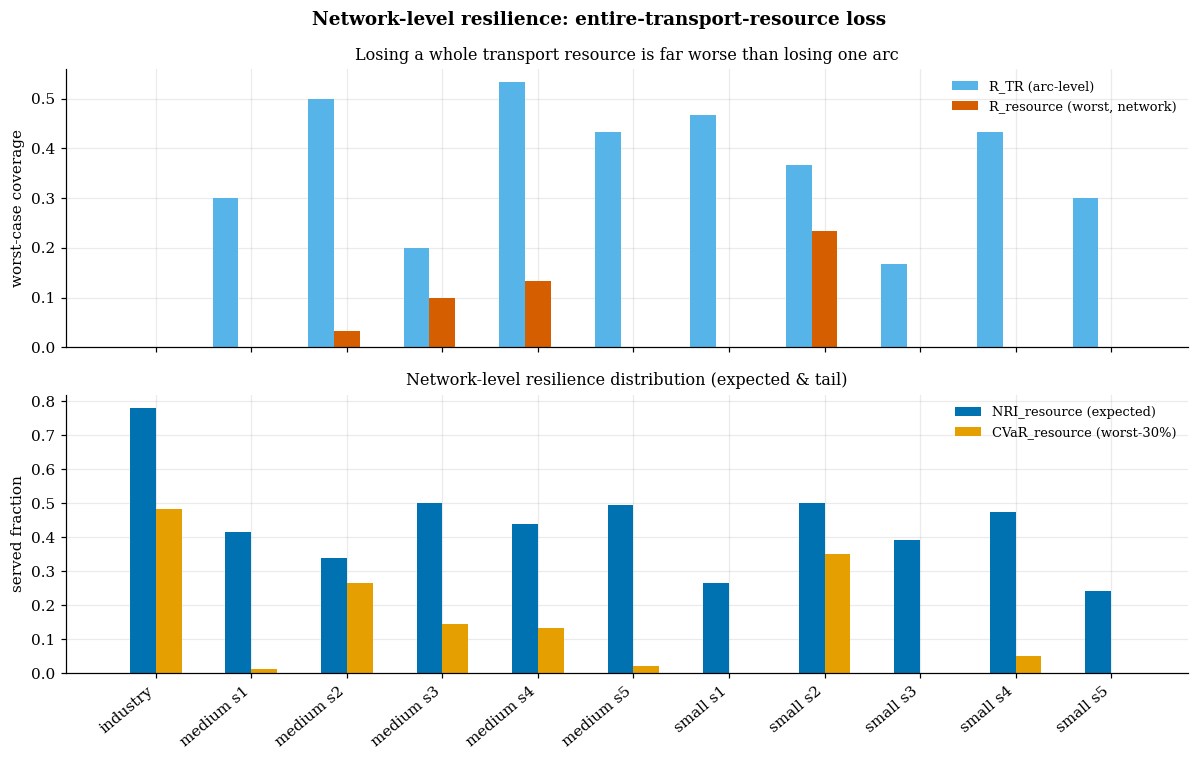

In [12]:
def fig4_network_resource(rr):
    """Network-level R_resource vs arc-level R_TR, plus expected/tail, at flow=(0,0)."""
    d = rr[(rr.w_net == 0) & (rr.w_flow == 0)].drop_duplicates("instance")
    insts = sorted(d.instance, key=lambda s: (not s.startswith("industry"), s))
    d = d.set_index("instance").loc[insts]
    x = np.arange(len(insts)); w = 0.27
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    axes[0].bar(x - w, d.r_tr_arc, w, label="R_TR (arc-level)", color="#56B4E9")
    axes[0].bar(x, d.r_resource, w, label="R_resource (worst, network)", color="#D55E00")
    axes[0].set_ylabel("worst-case coverage")
    axes[0].set_title("Losing a whole transport resource is far worse than losing one arc")
    axes[0].legend()
    axes[1].bar(x - w/2, d.nri_resource, w, label="NRI_resource (expected)", color="#0072B2")
    axes[1].bar(x + w/2, d.cvar_resource, w, label="CVaR_resource (worst-30%)", color="#E69F00")
    axes[1].set_ylabel("served fraction")
    axes[1].set_title("Network-level resilience distribution (expected & tail)")
    axes[1].legend()
    axes[1].set_xticks(x); axes[1].set_xticklabels([short(i) for i in insts], rotation=40, ha="right")
    fig.suptitle("Network-level resilience: entire-transport-resource loss", fontweight="bold")
    fig.tight_layout(); save(fig, "fig4_network_resource")

fig4_network_resource(rr_milp)

**Fig 5** — Anti-concentration dose-response on the industrial instance.

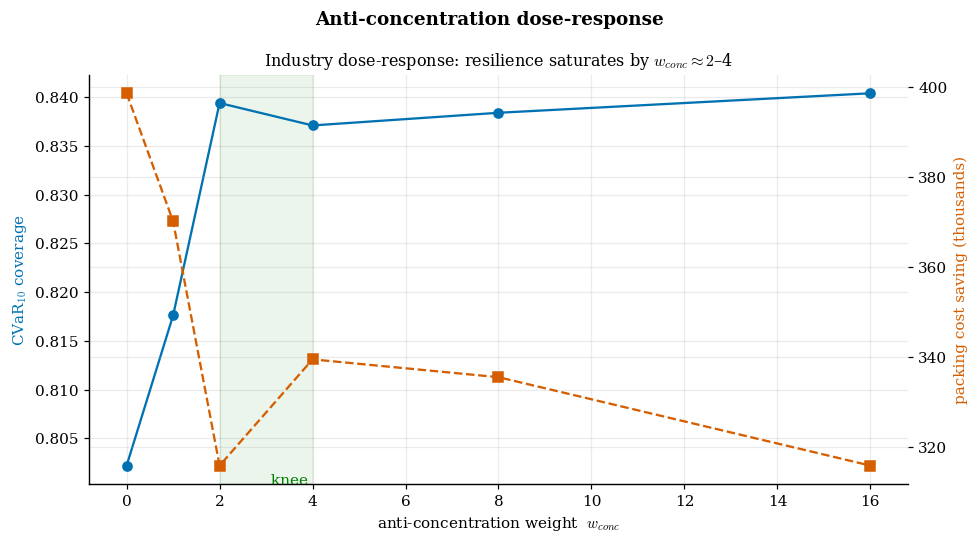

In [13]:
def fig5_dose_response(dose):
    """Industry w_conc dose-response: resilience vs cost_saving (the knee)."""
    d = dose[dose.config.str.startswith(("baseline", "conc"))].copy()
    d["wc"] = d["w_conc"].astype(float)
    d = d.sort_values("wc")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(d.wc, d.cov_cvar10, "o-", color="#0072B2", label="CVaR$_{10}$ coverage")
    ax.set_xlabel("anti-concentration weight  $w_{conc}$"); ax.set_ylabel("CVaR$_{10}$ coverage", color="#0072B2")
    ax2 = ax.twinx()
    ax2.plot(d.wc, d.cost_saving / 1e3, "s--", color="#D55E00", label="cost saving")
    ax2.set_ylabel("packing cost saving (thousands)", color="#D55E00")
    ax.axvspan(2, 4, color="green", alpha=0.08); ax.text(3, ax.get_ylim()[0], " knee", color="green")
    ax.set_title("Industry dose-response: resilience saturates by $w_{conc}\\approx2$–4")
    fig.suptitle("Anti-concentration dose-response", fontweight="bold")
    fig.tight_layout(); save(fig, "fig5_dose_response")

fig5_dose_response(dose)

**Fig 6** — Parametric $\alpha$ verdict flips with survivor strategy.

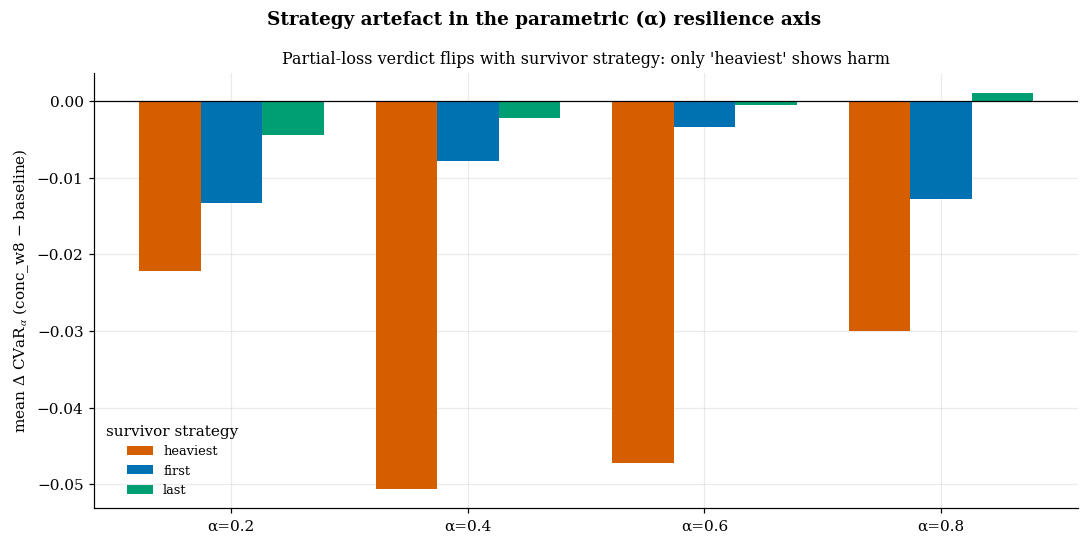

In [14]:
def fig6_strategy_artefact(sp):
    """conc_w8 CVaR_alpha delta vs baseline, per survivor strategy (the artefact)."""
    alphas = [0.2, 0.4, 0.6, 0.8]
    strs = ["heaviest", "first", "last"]
    base = sp[sp.config == "baseline"].set_index(["instance", "strategy"])
    conc = sp[sp.config == "conc_w8"].set_index(["instance", "strategy"])
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(alphas)); w = 0.26
    col = {"heaviest": "#D55E00", "first": "#0072B2", "last": "#009E73"}
    for j, st in enumerate(strs):
        deltas = []
        for a in alphas:
            c = conc.xs(st, level="strategy")[f"cvar_alpha_{a}"]
            b = base.xs(st, level="strategy")[f"cvar_alpha_{a}"]
            deltas.append((c - b).mean())
        ax.bar(x + (j-1)*w, deltas, w, label=st, color=col[st])
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f"α={a}" for a in alphas])
    ax.set_ylabel("mean Δ CVaR$_α$ (conc_w8 − baseline)")
    ax.set_title("Partial-loss verdict flips with survivor strategy: only 'heaviest' shows harm")
    ax.legend(title="survivor strategy")
    fig.suptitle("Strategy artefact in the parametric (α) resilience axis", fontweight="bold")
    fig.tight_layout(); save(fig, "fig6_strategy_artefact")

fig6_strategy_artefact(sp)

### Cost figures

**Cost 1** — Stage-1 flow vs Stage-2 packing dispatch cost.

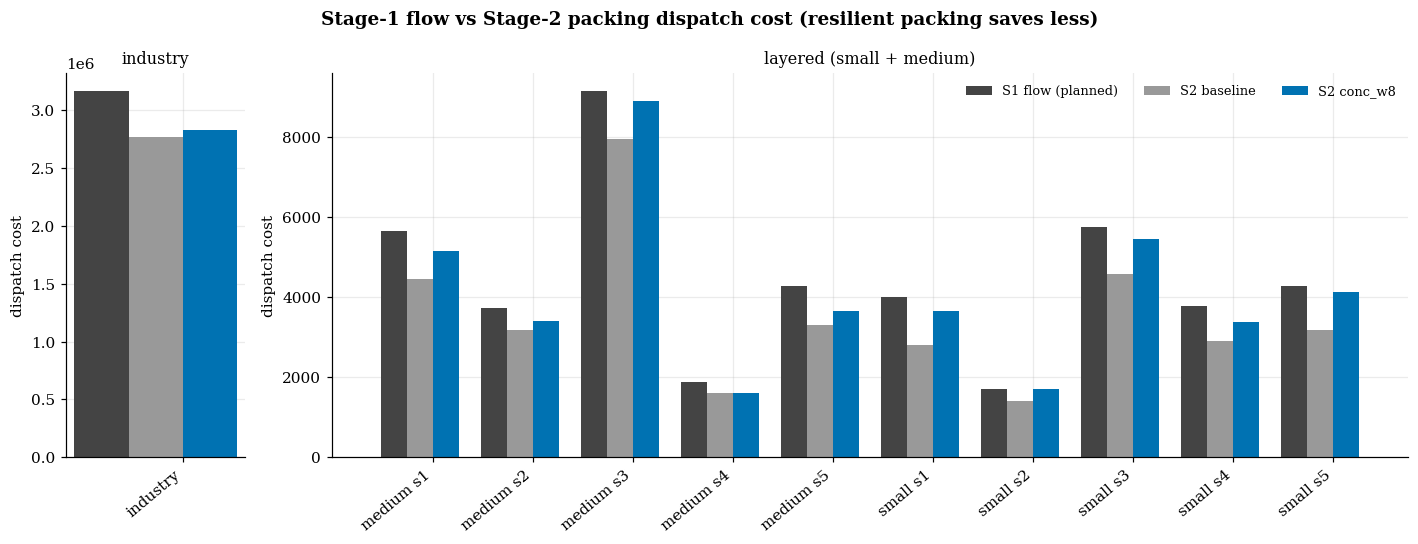

In [15]:
def base(df):
    """Canonical flow point: MILP, cost-optimal flow (w_net=w_flow=0)."""
    d = df[(df.flow_solver == "milp") & (df.w_net == 0) & (df.w_flow == 0)].copy()
    d["save_pct"] = np.where(d.s1_dispatch_cost > 0,
                             d.cost_saving / d.s1_dispatch_cost * 100, np.nan)
    return d

def cost1_s1_vs_s2(d):
    """Stage-1 flow cost vs Stage-2 packing cost (baseline & conc), per instance."""
    insts = inst_order(d.instance.unique())
    piv = d.pivot_table(index="instance", columns="config", values="s2_dispatch_cost")
    s1 = d.groupby("instance").s1_dispatch_cost.first()
    # split industry (millions) from layered (thousands) into two panels for scale
    groups = [("industry", [i for i in insts if i.startswith("industry")]),
              ("layered (small + medium)", [i for i in insts if not i.startswith("industry")])]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 6]})
    for ax, (title, gi) in zip(axes, groups):
        x = np.arange(len(gi)); w = 0.26
        ax.bar(x - 1.5*w, [s1[i] for i in gi], w, label="S1 flow (planned)", color="#444")
        ax.bar(x - 0.5*w, [piv.loc[i, "baseline"] for i in gi], w, label="S2 baseline", color=CONFIG_COLOR["baseline"])
        ax.bar(x + 0.5*w, [piv.loc[i, "conc_w8"] for i in gi], w, label="S2 conc_w8", color=CONFIG_COLOR["conc_w8"])
        ax.set_xticks(x); ax.set_xticklabels([short(i) for i in gi], rotation=40, ha="right")
        ax.set_title(title); ax.set_ylabel("dispatch cost")
    axes[1].legend(ncol=3, loc="upper right")
    fig.suptitle("Stage-1 flow vs Stage-2 packing dispatch cost (resilient packing saves less)",
                 fontweight="bold")
    fig.tight_layout(); save(fig, "cost1_s1_vs_s2")

cost1_s1_vs_s2(base(df))

**Cost 2** — Stage-2 cost-saving (%) heatmap, config × instance.

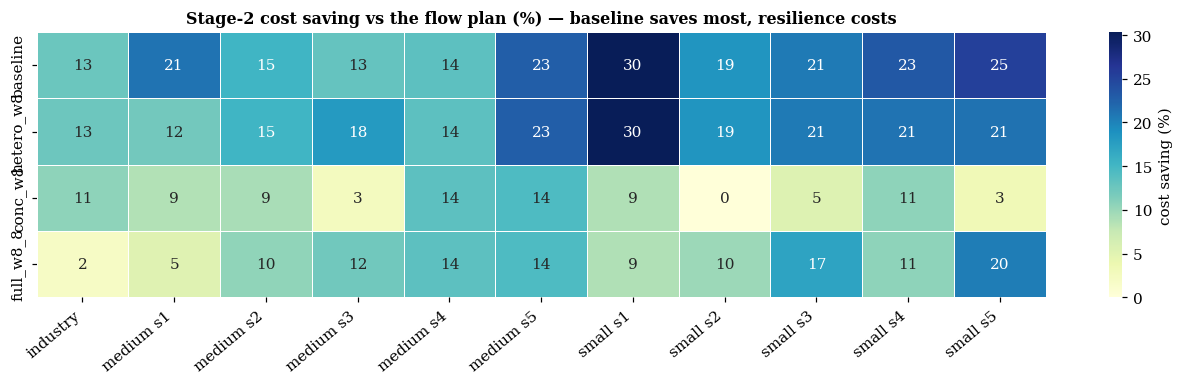

In [16]:
def cost2_saving_heatmap(d):
    """Cost-saving % heatmap: config x instance."""
    insts = inst_order(d.instance.unique())
    piv = d.pivot_table(index="config", columns="instance", values="save_pct").reindex(
        index=CONFIG_ORDER, columns=insts)
    fig, ax = plt.subplots(figsize=(12, 3.6))
    sns.heatmap(piv, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "cost saving (%)"},
                ax=ax, linewidths=0.5)
    ax.set_xticklabels([short(i) for i in insts], rotation=40, ha="right")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title("Stage-2 cost saving vs the flow plan (%) — baseline saves most, resilience costs",
                 fontweight="bold")
    fig.tight_layout(); save(fig, "cost2_saving_heatmap")

cost2_saving_heatmap(base(df))

**Cost 3** — Is the packing earning its cost? Δcost vs Δ$\mathrm{CVaR}_{10}$.

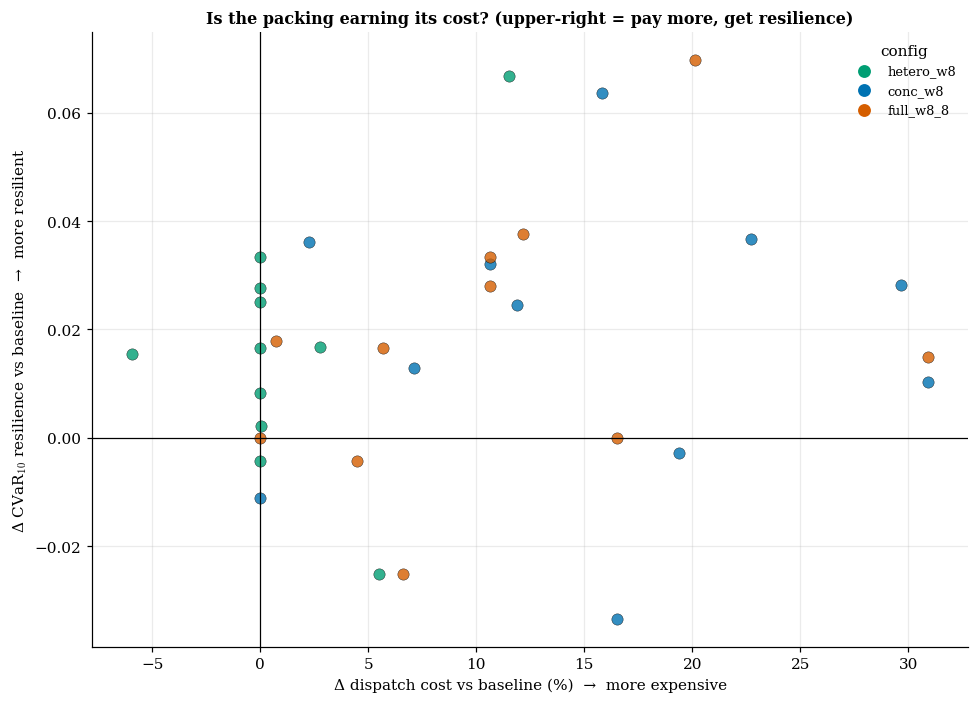

In [17]:
def cost3_earning_quadrant(d):
    """Δ dispatch cost % vs Δ CVaR10 relative to baseline, per (instance, config)."""
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for inst, g in d.groupby("instance"):
        g = g.set_index("config")
        if "baseline" not in g.index:
            continue
        b_cost, b_cv = g.loc["baseline", "s2_dispatch_cost"], g.loc["baseline", "cov_cvar10"]
        for cfg in ["hetero_w8", "conc_w8", "full_w8_8"]:
            if cfg not in g.index:
                continue
            dc = (g.loc[cfg, "s2_dispatch_cost"] - b_cost) / b_cost * 100
            dr = g.loc[cfg, "cov_cvar10"] - b_cv
            ax.scatter(dc, dr, color=CONFIG_COLOR[cfg], s=55, alpha=0.8,
                       edgecolor="k", linewidth=0.3)
    for cfg in ["hetero_w8", "conc_w8", "full_w8_8"]:
        ax.scatter([], [], color=CONFIG_COLOR[cfg], s=55, label=cfg)
    ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("Δ dispatch cost vs baseline (%)  →  more expensive")
    ax.set_ylabel("Δ CVaR$_{10}$ resilience vs baseline  →  more resilient")
    ax.set_title("Is the packing earning its cost? (upper-right = pay more, get resilience)",
                 fontweight="bold")
    ax.legend(title="config")
    fig.tight_layout(); save(fig, "cost3_earning_quadrant")

cost3_earning_quadrant(base(df))

**Cost 4** — Cost–resilience frontier across instances.

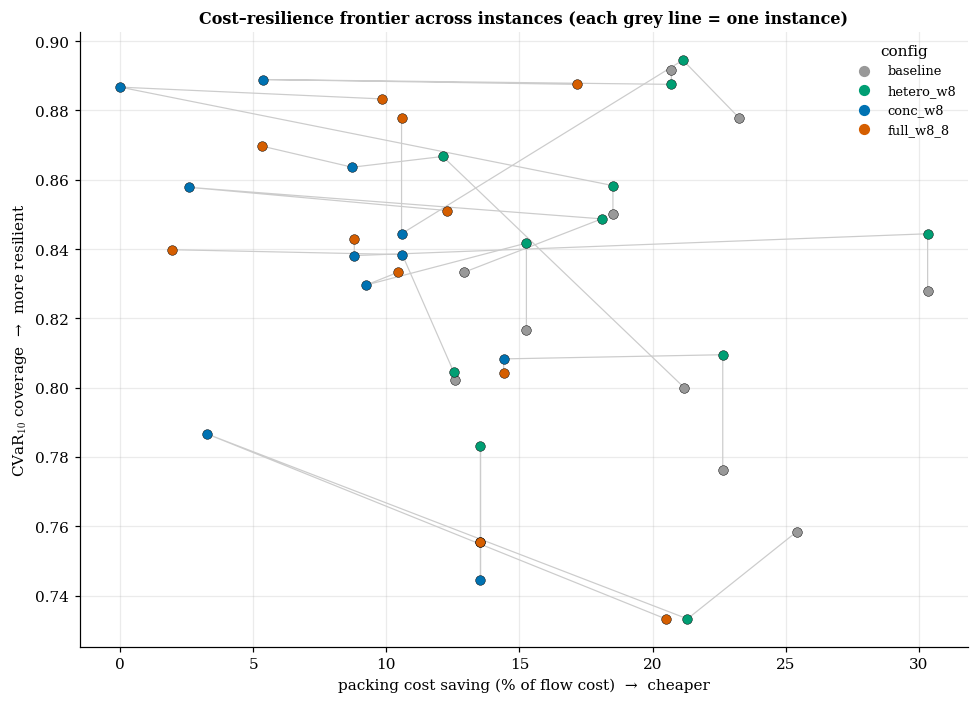

In [18]:
def cost4_frontier(d):
    """Cost-vs-resilience frontier: cost_saving % (x) vs CVaR10 (y), configs connected."""
    insts = inst_order(d.instance.unique())
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for inst in insts:
        g = d[d.instance == inst].set_index("config").reindex(CONFIG_ORDER)
        ax.plot(g.save_pct, g.cov_cvar10, "-", color="#ccc", lw=0.8, zorder=1)
        for cfg in CONFIG_ORDER:
            if cfg in g.index and pd.notna(g.loc[cfg, "save_pct"]):
                ax.scatter(g.loc[cfg, "save_pct"], g.loc[cfg, "cov_cvar10"],
                           color=CONFIG_COLOR[cfg], s=40, zorder=2, edgecolor="k", linewidth=0.3)
    for cfg in CONFIG_ORDER:
        ax.scatter([], [], color=CONFIG_COLOR[cfg], s=40, label=cfg)
    ax.set_xlabel("packing cost saving (% of flow cost)  →  cheaper")
    ax.set_ylabel("CVaR$_{10}$ coverage  →  more resilient")
    ax.set_title("Cost–resilience frontier across instances (each grey line = one instance)",
                 fontweight="bold")
    ax.legend(title="config")
    fig.tight_layout(); save(fig, "cost4_frontier")

cost4_frontier(base(df))

### Lever and tradeoff figures

**Lever 1** — Layered: flow-cost increase vs each metric; packing buys NRI, the network lever buys $R_\alpha$.

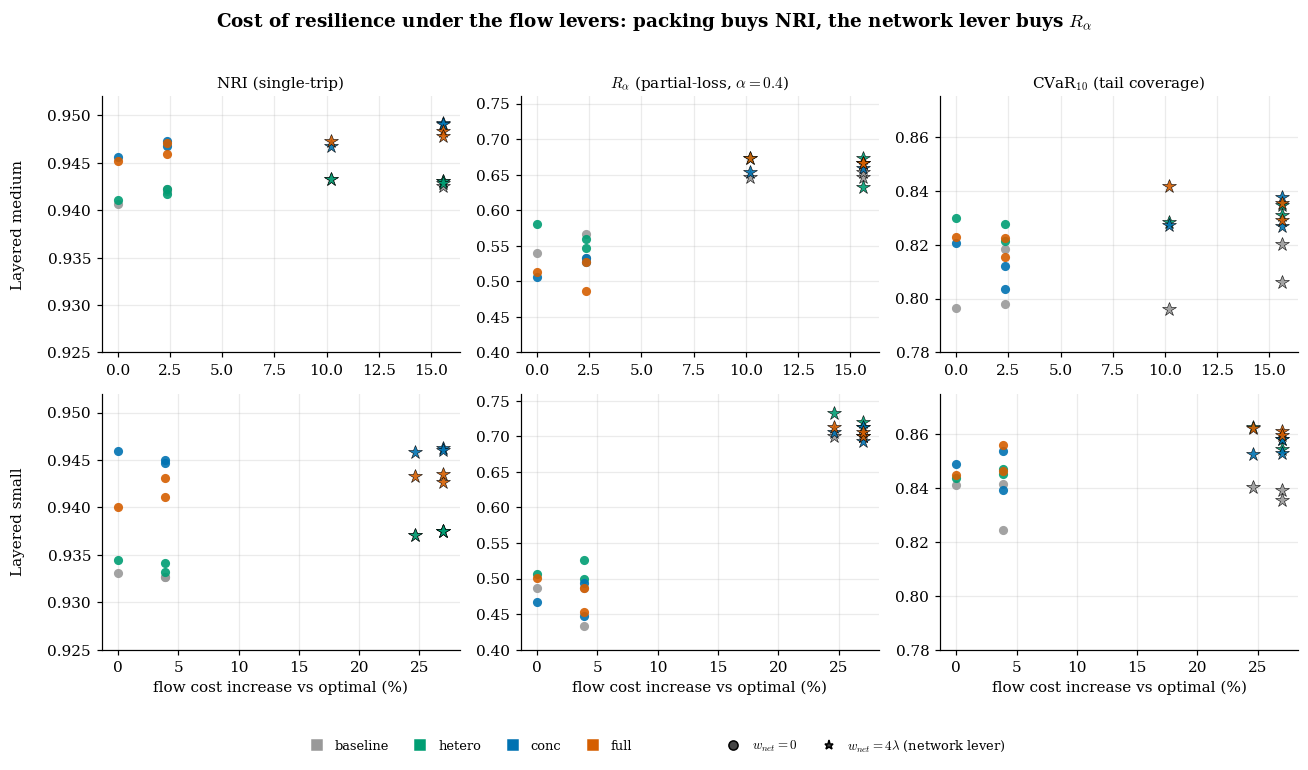

In [19]:
def lever_layered(d):
    """Layered (mean over 5 seeds): flow-cost rise vs three metrics, coloured by
    packing config, marker by network lever. One row per size group."""
    metrics = [("nri", "NRI (single-trip)", (0.925, 0.952)),
               ("r_alpha_single_0.4", r"$R_\alpha$ (partial-loss, $\alpha{=}0.4$)", (0.40, 0.76)),
               ("cov_cvar10", r"CVaR$_{10}$ (tail coverage)", (0.78, 0.875))]
    groups = [("medium", "Layered medium"), ("small", "Layered small")]
    fig, axes = plt.subplots(len(groups), len(metrics), figsize=(12, 7), sharex="row")
    for r, (grp, gtitle) in enumerate(groups):
        g = (d[d.grp == grp]
             .groupby(["config", "lambda_net", "lambda_flow"])
             .agg(cost_rise=("cost_rise", "mean"),
                  **{m: (m, "mean") for m, _, _ in metrics})
             .reset_index())
        for c, (m, mlab, ylim) in enumerate(metrics):
            ax = axes[r, c]
            for cfg in CFG_ORDER:
                for net, mk in NET_MARK.items():
                    s = g[(g.config == cfg) & (g.lambda_net == net)].sort_values("cost_rise")
                    if s.empty:
                        continue
                    ax.plot(s.cost_rise, s[m], mk, color=CFG_COLOR[cfg],
                            ms=9 if mk == "*" else 6, alpha=0.9,
                            mec="k" if mk == "*" else "none", mew=0.4)
            if r == 0:
                ax.set_title(mlab, fontsize=10)
            if c == 0:
                ax.set_ylabel(f"{gtitle}\n", fontsize=10)
            ax.set_ylim(*ylim)
            if r == len(groups) - 1:
                ax.set_xlabel("flow cost increase vs optimal (%)")
    # one shared legend row: packing colours, then flow-lever markers
    sep = Line2D([], [], ls="none", label="     ")
    cfg_handles = [Line2D([], [], marker="s", ls="none", color=CFG_COLOR[c],
                          label=CFG_LABEL[c]) for c in CFG_ORDER]
    net_handles = [Line2D([], [], marker=NET_MARK[n], ls="none", color="#444",
                          mec="k", label=NET_LABEL[n]) for n in NET_MARK]
    fig.legend(handles=cfg_handles + [sep] + net_handles, ncol=7,
               loc="upper center", bbox_to_anchor=(0.5, 0.05),
               columnspacing=1.4, handletextpad=0.4)
    fig.suptitle("Cost of resilience under the flow levers: packing buys NRI, the "
                 "network lever buys $R_\\alpha$", fontweight="bold")
    fig.tight_layout(rect=(0, 0.07, 1, 0.97))
    _save(fig, "lever_layered_cost_metrics")

lever_layered(DLEV)

**Lever 2** — Industrial: resilience vs flow cost under the network and redundancy levers.

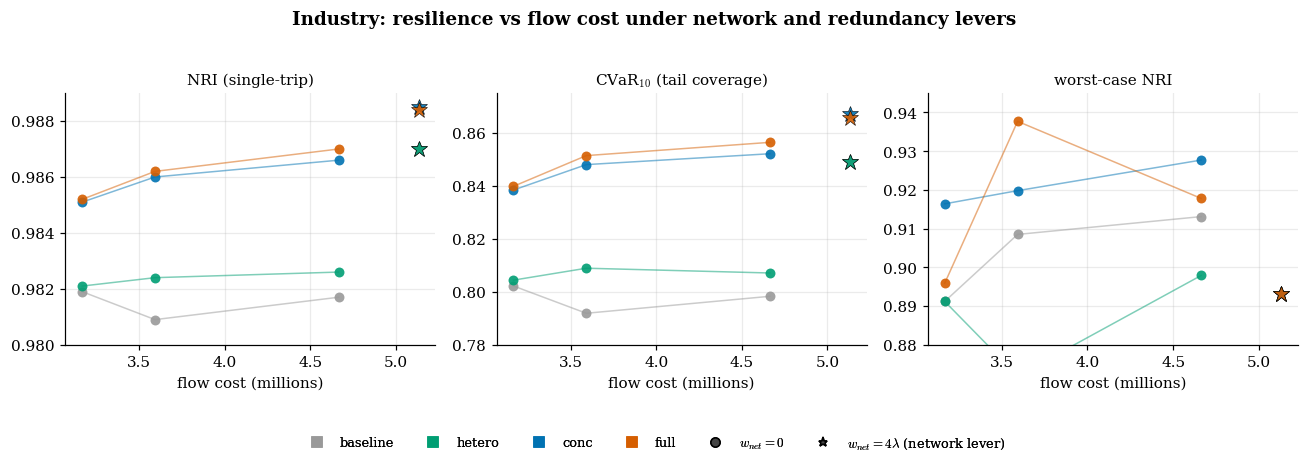

In [20]:
def lever_industry(d):
    """Industry: flow cost (absolute, millions) vs NRI / CVaR10 / worst-case NRI,
    coloured by packing config, marker by network lever. R_alpha omitted (==0)."""
    g = d[d.instance == "industry_test_1"].copy()
    g["flow_M"] = g.flow_cost / 1e6
    metrics = [("nri", "NRI (single-trip)", (0.980, 0.989)),
               ("cov_cvar10", r"CVaR$_{10}$ (tail coverage)", (0.78, 0.875)),
               ("nri_worst", "worst-case NRI", (0.88, 0.945))]
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 4.0))
    for c, (m, mlab, ylim) in enumerate(metrics):
        ax = axes[c]
        for cfg in CFG_ORDER:
            for net, mk in NET_MARK.items():
                s = g[(g.config == cfg) & (g.lambda_net == net)].sort_values("flow_M")
                if s.empty:
                    continue
                # connect the flow-redundancy sweep (net=0) with a faint line
                if net == 0.0:
                    ax.plot(s.flow_M, s[m], "-", color=CFG_COLOR[cfg], lw=1, alpha=0.5, zorder=1)
                ax.plot(s.flow_M, s[m], mk, color=CFG_COLOR[cfg],
                        ms=11 if mk == "*" else 6.5, alpha=0.9,
                        mec="k" if mk == "*" else "none", mew=0.4, zorder=2)
        ax.set_title(mlab, fontsize=10)
        ax.set_xlabel("flow cost (millions)")
        ax.set_ylim(*ylim)
    cfg_handles = [Line2D([], [], marker="s", ls="none", color=CFG_COLOR[c],
                          label=CFG_LABEL[c]) for c in CFG_ORDER]
    net_handles = [Line2D([], [], marker=NET_MARK[n], ls="none", color="#444",
                          mec="k", label=NET_LABEL[n]) for n in NET_MARK]
    leg1 = fig.legend(handles=cfg_handles + net_handles, ncol=6,
                      loc="upper center", bbox_to_anchor=(0.5, 0.04))
    fig.add_artist(leg1)
    fig.suptitle("Industry: resilience vs flow cost under network and redundancy levers",
                 fontweight="bold")
    fig.tight_layout(rect=(0, 0.08, 1, 0.96))
    _save(fig, "lever_industry_cost_metrics")

lever_industry(DLEV)

**Lever 3** — $R_\alpha$ is governed by the exposure weight, not the packing.

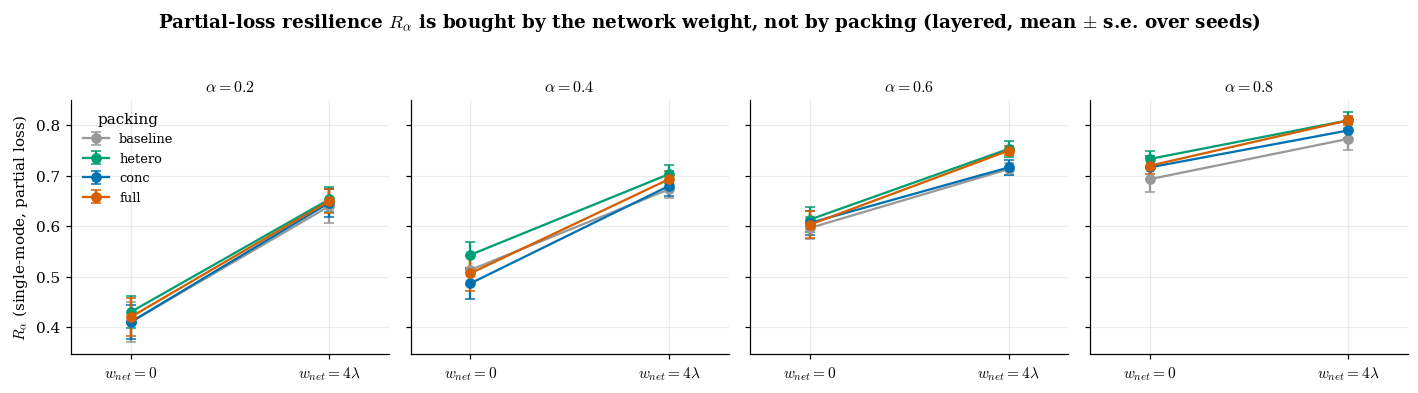

In [21]:
def ralpha_vs_wnet(d):
    """Isolated finding: R_alpha (partial-loss worst case) is bought by the network
    weight, not by packing. Layered only (R_alpha == 0 on industry). x = w_net setting,
    one line per packing config, panels per alpha level, mean +/- s.e. over seeds."""
    alphas = [0.2, 0.4, 0.6, 0.8]
    g = d[d.grp.isin(["medium", "small"]) & (d.lambda_flow == 0)].copy()
    fig, axes = plt.subplots(1, len(alphas), figsize=(13, 3.6), sharey=True)
    for c, a in enumerate(alphas):
        ax = axes[c]
        col = f"r_alpha_single_{a}"
        for cfg in CFG_ORDER:
            s = g[g.config == cfg]
            agg = s.groupby("lambda_net")[col].agg(["mean", "sem"]).reindex([0.0, 4.0])
            ax.errorbar([0, 1], agg["mean"], yerr=agg["sem"], marker="o", ms=6,
                        color=CFG_COLOR[cfg], capsize=3, lw=1.5,
                        label=CFG_LABEL[cfg] if c == 0 else None)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["$w_{net}=0$", r"$w_{net}=4\lambda$"])
        ax.set_xlim(-0.3, 1.3)
        ax.set_title(rf"$\alpha={a}$")
        if c == 0:
            ax.set_ylabel(r"$R_\alpha$ (single-mode, partial loss)")
    axes[0].legend(title="packing", loc="upper left")
    fig.suptitle(r"Partial-loss resilience $R_\alpha$ is bought by the network weight, "
                 "not by packing (layered, mean $\\pm$ s.e. over seeds)",
                 fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    _save(fig, "lever_ralpha_vs_wnet")

ralpha_vs_wnet(DLEV)

**Tradeoff 1** — Cost of disruption tolerance: NRI vs dispatch-cost increase (w_net lever only).

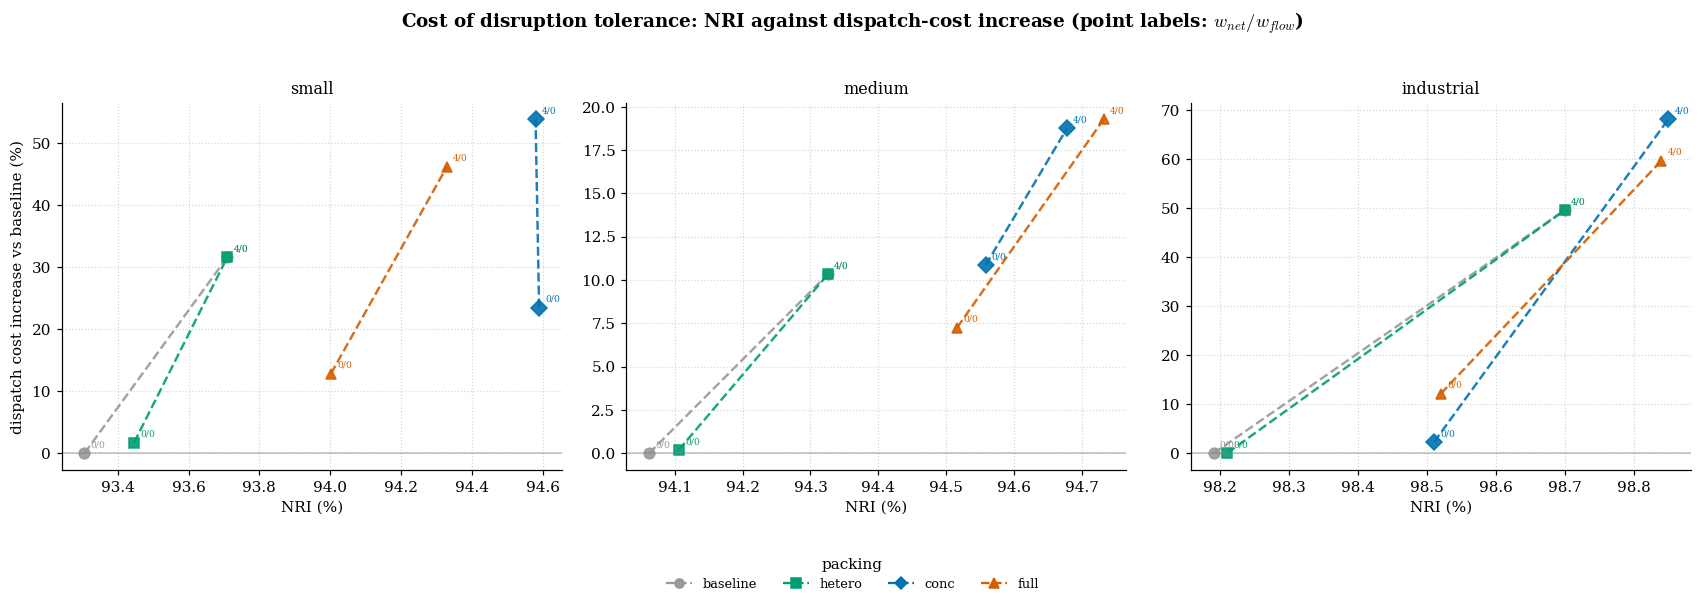

In [22]:
def tradeoff(d, metric_col, metric_label, stem, pct_metric=True):
    """Per size: metric (x) vs relative dispatch-cost increase (y), per config, over the
    flow-weight grid. Cost is relative to the baseline cost-optimal plan of that size."""
    sizes = [s for s in SIZES if s in set(d["size"])]
    fig, axes = plt.subplots(1, len(sizes), figsize=(5.2 * len(sizes), 5.2), squeeze=False)
    axes = axes[0]
    for ax, size in zip(axes, sizes):
        ss = d[d["size"] == size]
        ref = ss[(ss.lambda_net == 0) & (ss.lambda_flow == 0) & (ss.config == "baseline")]
        c0 = ref["s2_dispatch_cost"].mean()
        if not c0 or np.isnan(c0):
            continue
        all_x = []
        for cfg in CFG_ORDER:
            g = (ss[ss.config == cfg]
                 .groupby(["lambda_net", "lambda_flow"])
                 .agg(m=(metric_col, "mean"), cost=("s2_dispatch_cost", "mean"))
                 .reset_index().sort_values("cost"))
            if g.empty:
                continue
            xv = g["m"] * (100 if pct_metric else 1)
            yv = (g["cost"] - c0) / c0 * 100
            all_x.extend(xv.tolist())
            ax.plot(xv, yv, MARKERS[cfg] + "--", lw=1.6, ms=7, alpha=0.9,
                    color=CFG_COLOR[cfg], label=CFG_LABEL[cfg])
            for wn, wf, x, y in zip(g.lambda_net, g.lambda_flow, xv, yv):
                ax.annotate(_wtag(wn, wf), (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=6, color=CFG_COLOR[cfg])
        ax.axhline(0, color="gray", lw=1, alpha=0.5)
        # degenerate panel: metric identically (near) zero at every weight
        if all_x and (max(all_x) - min(all_x)) < 1e-6:
            ax.set_xlim(-5, 5)
            ax.text(0.5, 0.5, f"{metric_label} $= 0$ at every weight\n(structural single point of failure)",
                    transform=ax.transAxes, ha="center", va="center", fontsize=8,
                    color="#555", style="italic")
        ax.set_title(size)
        ax.set_xlabel(metric_label + (" (%)" if pct_metric else ""))
        ax.grid(True, ls=":", alpha=0.5)
    axes[0].set_ylabel("dispatch cost increase vs baseline (%)")
    handles = [Line2D([], [], marker=MARKERS[c], ls="--", color=CFG_COLOR[c],
                      label=CFG_LABEL[c]) for c in CFG_ORDER]
    fig.legend(handles=handles, title="packing", ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, 0.045))
    fig.suptitle(f"Cost of disruption tolerance: {metric_label} against dispatch-cost "
                 "increase (point labels: $w_{net}/w_{flow}$)", fontweight="bold")
    fig.tight_layout(rect=(0, 0.07, 1, 0.96))
    _save(fig, stem)

# w_net lever only (lambda_flow == 0 -> just the (0,0) and (4,0) points)
DN = DTD[DTD.lambda_flow == 0]
tradeoff(DN, "nri", "NRI", "tradeoff_nri")

**Tradeoff 2** — Cost of disruption tolerance: CVaR$_{10}$ vs dispatch-cost increase (w_net lever only).

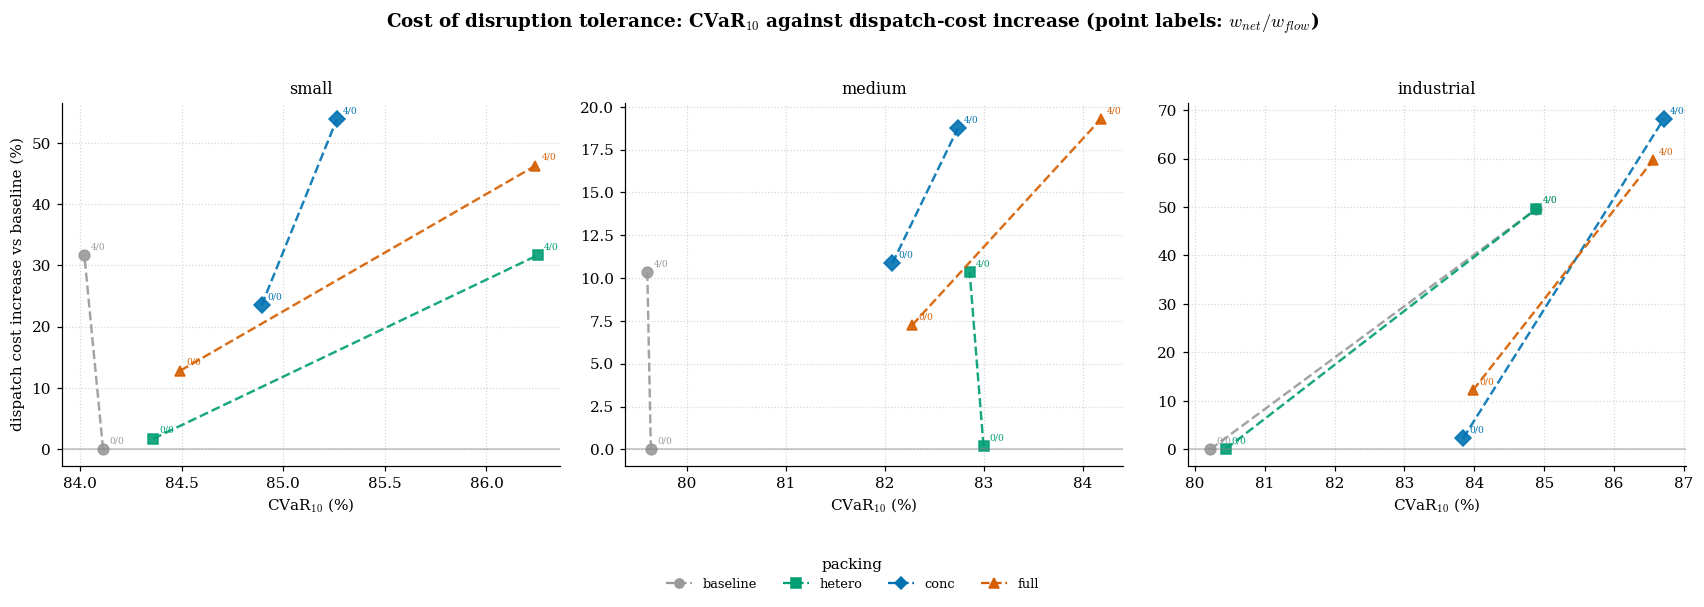

In [23]:
def tradeoff(d, metric_col, metric_label, stem, pct_metric=True):
    """Per size: metric (x) vs relative dispatch-cost increase (y), per config, over the
    flow-weight grid. Cost is relative to the baseline cost-optimal plan of that size."""
    sizes = [s for s in SIZES if s in set(d["size"])]
    fig, axes = plt.subplots(1, len(sizes), figsize=(5.2 * len(sizes), 5.2), squeeze=False)
    axes = axes[0]
    for ax, size in zip(axes, sizes):
        ss = d[d["size"] == size]
        ref = ss[(ss.lambda_net == 0) & (ss.lambda_flow == 0) & (ss.config == "baseline")]
        c0 = ref["s2_dispatch_cost"].mean()
        if not c0 or np.isnan(c0):
            continue
        all_x = []
        for cfg in CFG_ORDER:
            g = (ss[ss.config == cfg]
                 .groupby(["lambda_net", "lambda_flow"])
                 .agg(m=(metric_col, "mean"), cost=("s2_dispatch_cost", "mean"))
                 .reset_index().sort_values("cost"))
            if g.empty:
                continue
            xv = g["m"] * (100 if pct_metric else 1)
            yv = (g["cost"] - c0) / c0 * 100
            all_x.extend(xv.tolist())
            ax.plot(xv, yv, MARKERS[cfg] + "--", lw=1.6, ms=7, alpha=0.9,
                    color=CFG_COLOR[cfg], label=CFG_LABEL[cfg])
            for wn, wf, x, y in zip(g.lambda_net, g.lambda_flow, xv, yv):
                ax.annotate(_wtag(wn, wf), (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=6, color=CFG_COLOR[cfg])
        ax.axhline(0, color="gray", lw=1, alpha=0.5)
        # degenerate panel: metric identically (near) zero at every weight
        if all_x and (max(all_x) - min(all_x)) < 1e-6:
            ax.set_xlim(-5, 5)
            ax.text(0.5, 0.5, f"{metric_label} $= 0$ at every weight\n(structural single point of failure)",
                    transform=ax.transAxes, ha="center", va="center", fontsize=8,
                    color="#555", style="italic")
        ax.set_title(size)
        ax.set_xlabel(metric_label + (" (%)" if pct_metric else ""))
        ax.grid(True, ls=":", alpha=0.5)
    axes[0].set_ylabel("dispatch cost increase vs baseline (%)")
    handles = [Line2D([], [], marker=MARKERS[c], ls="--", color=CFG_COLOR[c],
                      label=CFG_LABEL[c]) for c in CFG_ORDER]
    fig.legend(handles=handles, title="packing", ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, 0.045))
    fig.suptitle(f"Cost of disruption tolerance: {metric_label} against dispatch-cost "
                 "increase (point labels: $w_{net}/w_{flow}$)", fontweight="bold")
    fig.tight_layout(rect=(0, 0.07, 1, 0.96))
    _save(fig, stem)

# w_net lever only
DC = DTD[DTD.lambda_flow == 0]
tradeoff(DC, "cov_cvar10", r"CVaR$_{10}$", "tradeoff_cvar10")

**Tradeoff 3** — Cost of disruption tolerance: $R_{TR}$ vs dispatch-cost increase (small + medium only; w_net lever only).

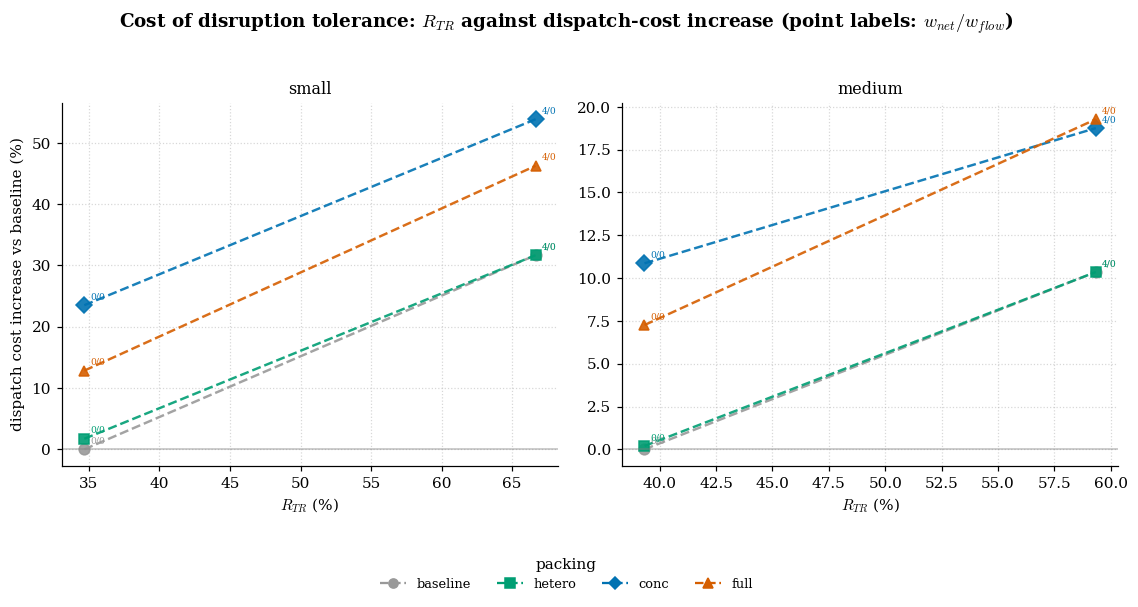

In [24]:
def tradeoff(d, metric_col, metric_label, stem, pct_metric=True):
    """Per size: metric (x) vs relative dispatch-cost increase (y), per config, over the
    flow-weight grid. Cost is relative to the baseline cost-optimal plan of that size."""
    sizes = [s for s in SIZES if s in set(d["size"])]
    fig, axes = plt.subplots(1, len(sizes), figsize=(5.2 * len(sizes), 5.2), squeeze=False)
    axes = axes[0]
    for ax, size in zip(axes, sizes):
        ss = d[d["size"] == size]
        ref = ss[(ss.lambda_net == 0) & (ss.lambda_flow == 0) & (ss.config == "baseline")]
        c0 = ref["s2_dispatch_cost"].mean()
        if not c0 or np.isnan(c0):
            continue
        all_x = []
        for cfg in CFG_ORDER:
            g = (ss[ss.config == cfg]
                 .groupby(["lambda_net", "lambda_flow"])
                 .agg(m=(metric_col, "mean"), cost=("s2_dispatch_cost", "mean"))
                 .reset_index().sort_values("cost"))
            if g.empty:
                continue
            xv = g["m"] * (100 if pct_metric else 1)
            yv = (g["cost"] - c0) / c0 * 100
            all_x.extend(xv.tolist())
            ax.plot(xv, yv, MARKERS[cfg] + "--", lw=1.6, ms=7, alpha=0.9,
                    color=CFG_COLOR[cfg], label=CFG_LABEL[cfg])
            for wn, wf, x, y in zip(g.lambda_net, g.lambda_flow, xv, yv):
                ax.annotate(_wtag(wn, wf), (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=6, color=CFG_COLOR[cfg])
        ax.axhline(0, color="gray", lw=1, alpha=0.5)
        # degenerate panel: metric identically (near) zero at every weight
        if all_x and (max(all_x) - min(all_x)) < 1e-6:
            ax.set_xlim(-5, 5)
            ax.text(0.5, 0.5, f"{metric_label} $= 0$ at every weight\n(structural single point of failure)",
                    transform=ax.transAxes, ha="center", va="center", fontsize=8,
                    color="#555", style="italic")
        ax.set_title(size)
        ax.set_xlabel(metric_label + (" (%)" if pct_metric else ""))
        ax.grid(True, ls=":", alpha=0.5)
    axes[0].set_ylabel("dispatch cost increase vs baseline (%)")
    handles = [Line2D([], [], marker=MARKERS[c], ls="--", color=CFG_COLOR[c],
                      label=CFG_LABEL[c]) for c in CFG_ORDER]
    fig.legend(handles=handles, title="packing", ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, 0.045))
    fig.suptitle(f"Cost of disruption tolerance: {metric_label} against dispatch-cost "
                 "increase (point labels: $w_{net}/w_{flow}$)", fontweight="bold")
    fig.tight_layout(rect=(0, 0.07, 1, 0.96))
    _save(fig, stem)

# small + medium instances, and the w_net lever only (lambda_flow == 0 -> just (0,0) and (4,0))
DR = DTD[DTD["size"].isin(["small", "medium"]) & (DTD.lambda_flow == 0)]
tradeoff(DR, "r_tr", r"$R_{TR}$", "tradeoff_rtr")

**Industry suite** — NRI and CVaR$_{10}$ for the industrial instance only (w_net lever only: the (0,0) and (4,0) points).

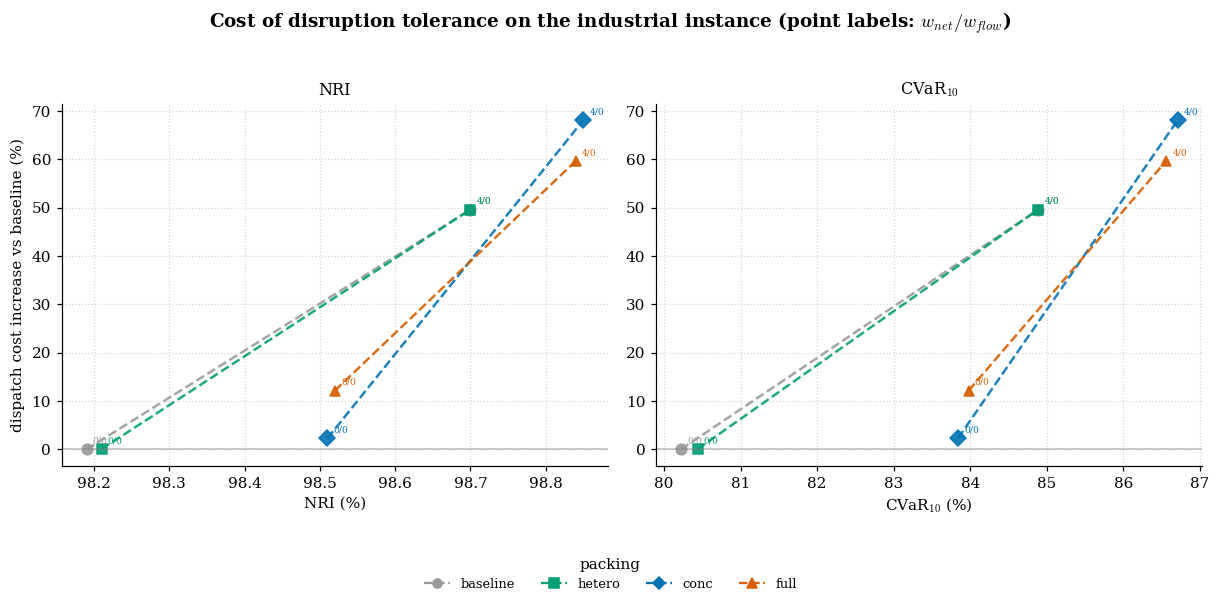

In [25]:
def single_instance_suite(d, metrics, stem, instance="industry_test_1"):
    """One instance, several metrics side by side: metric (x) vs relative dispatch-cost
    increase (y), per config, over the full flow-weight grid. `metrics` is a list of
    (column, label) pairs. Cost is relative to that instance's baseline cost-optimal plan."""
    g0 = d[d.instance == instance]
    c0 = g0[(g0.lambda_net == 0) & (g0.lambda_flow == 0)
            & (g0.config == "baseline")]["s2_dispatch_cost"].mean()
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.6 * len(metrics), 5.2), squeeze=False)
    axes = axes[0]
    for ax, (col, lab) in zip(axes, metrics):
        for cfg in CFG_ORDER:
            g = (g0[g0.config == cfg]
                 .groupby(["lambda_net", "lambda_flow"])
                 .agg(m=(col, "mean"), cost=("s2_dispatch_cost", "mean"))
                 .reset_index().sort_values("cost"))
            if g.empty:
                continue
            xv, yv = g["m"] * 100, (g["cost"] - c0) / c0 * 100
            ax.plot(xv, yv, MARKERS[cfg] + "--", lw=1.6, ms=7, alpha=0.9,
                    color=CFG_COLOR[cfg], label=CFG_LABEL[cfg])
            for wn, wf, x, y in zip(g.lambda_net, g.lambda_flow, xv, yv):
                ax.annotate(_wtag(wn, wf), (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=6, color=CFG_COLOR[cfg])
        ax.axhline(0, color="gray", lw=1, alpha=0.5)
        ax.set_title(lab); ax.set_xlabel(lab + " (%)"); ax.grid(True, ls=":", alpha=0.5)
    axes[0].set_ylabel("dispatch cost increase vs baseline (%)")
    handles = [Line2D([], [], marker=MARKERS[c], ls="--", color=CFG_COLOR[c],
                      label=CFG_LABEL[c]) for c in CFG_ORDER]
    fig.legend(handles=handles, title="packing", ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, 0.045))
    name = "industrial" if instance.startswith("industry") else instance
    fig.suptitle(f"Cost of disruption tolerance on the {name} instance "
                 "(point labels: $w_{net}/w_{flow}$)", fontweight="bold")
    fig.tight_layout(rect=(0, 0.07, 1, 0.96))
    _save(fig, stem)

# industrial instance, w_net lever only (lambda_flow == 0)
DI = DTD[DTD.lambda_flow == 0]
single_instance_suite(DI, [("nri", "NRI"), ("cov_cvar10", r"CVaR$_{10}$")],
                      "tradeoff_industry_nri_cvar")

**Small $R_\alpha$ suite** — $R_\alpha$ at $\alpha{=}0.2$, single and global scope, small instances (seed-averaged; w_net lever only).

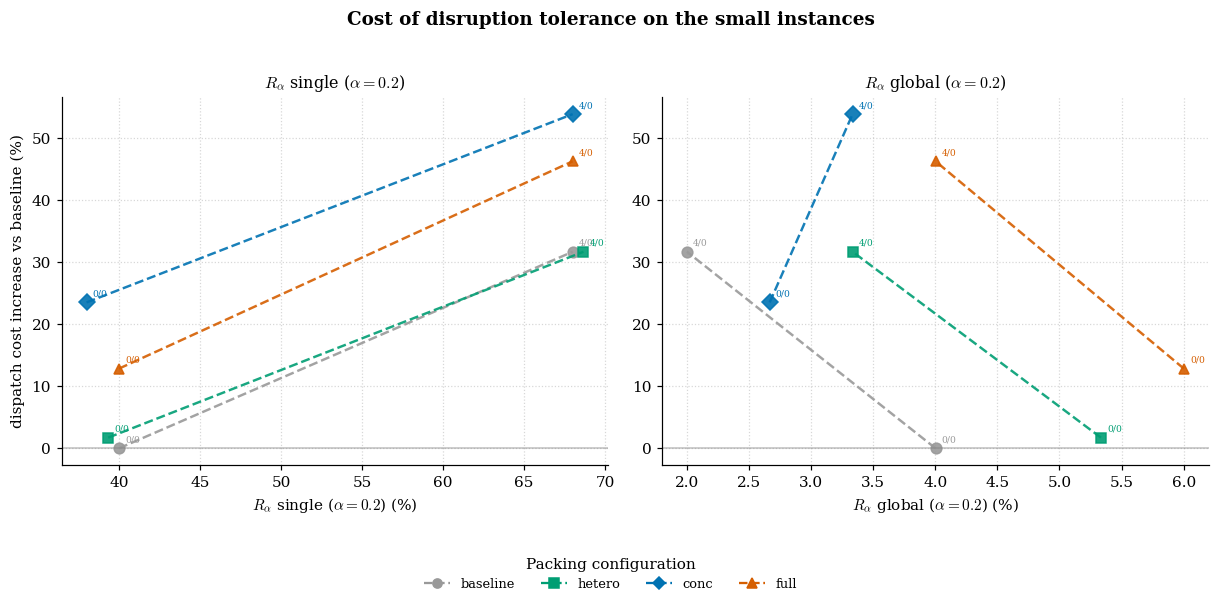

In [26]:
def size_suite(d, size, metrics, stem):
    """All instances of one size (seed-averaged): metric (x) vs relative dispatch-cost
    increase (y), per config, over the flow-weight grid present in `d`. `metrics` is a list
    of (column, label) pairs. Cost is relative to the size's baseline cost-optimal plan."""
    g0 = d[d["size"] == size]
    c0 = g0[(g0.lambda_net == 0) & (g0.lambda_flow == 0)
            & (g0.config == "baseline")]["s2_dispatch_cost"].mean()
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.6 * len(metrics), 5.2), squeeze=False)
    axes = axes[0]
    for ax, (col, lab) in zip(axes, metrics):
        for cfg in CFG_ORDER:
            g = (g0[g0.config == cfg]
                 .groupby(["lambda_net", "lambda_flow"])
                 .agg(m=(col, "mean"), cost=("s2_dispatch_cost", "mean"))
                 .reset_index().sort_values("cost"))
            if g.empty:
                continue
            xv, yv = g["m"] * 100, (g["cost"] - c0) / c0 * 100
            ax.plot(xv, yv, MARKERS[cfg] + "--", lw=1.6, ms=7, alpha=0.9,
                    color=CFG_COLOR[cfg], label=CFG_LABEL[cfg])
            for wn, wf, x, y in zip(g.lambda_net, g.lambda_flow, xv, yv):
                ax.annotate(_wtag(wn, wf), (x, y), textcoords="offset points",
                            xytext=(4, 4), fontsize=6, color=CFG_COLOR[cfg])
        ax.axhline(0, color="gray", lw=1, alpha=0.5)
        ax.set_title(lab); ax.set_xlabel(lab + " (%)"); ax.grid(True, ls=":", alpha=0.5)
    axes[0].set_ylabel("dispatch cost increase vs baseline (%)")
    handles = [Line2D([], [], marker=MARKERS[c], ls="--", color=CFG_COLOR[c],
                      label=CFG_LABEL[c]) for c in CFG_ORDER]
    fig.legend(handles=handles, title="Packing configuration", ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, 0.045))
    fig.suptitle(f"Cost of disruption tolerance on the {size} instances",
                 fontweight="bold")
    fig.tight_layout(rect=(0, 0.07, 1, 0.96))
    _save(fig, stem)

# small instances, w_net lever only (lambda_flow == 0)
DS = DTD[DTD.lambda_flow == 0]
size_suite(DS, "small",
           [("r_alpha_single_0.2", r"$R_\alpha$ single ($\alpha{=}0.2$)"),
            ("r_alpha_global_0.2", r"$R_\alpha$ global ($\alpha{=}0.2$)")],
           "tradeoff_small_ralpha02")

**Small $R_\alpha$ suite, $\alpha{=}0.4$** — same as above at $\alpha{=}0.4$, where the packing spread is larger (`size_suite` is already defined above).

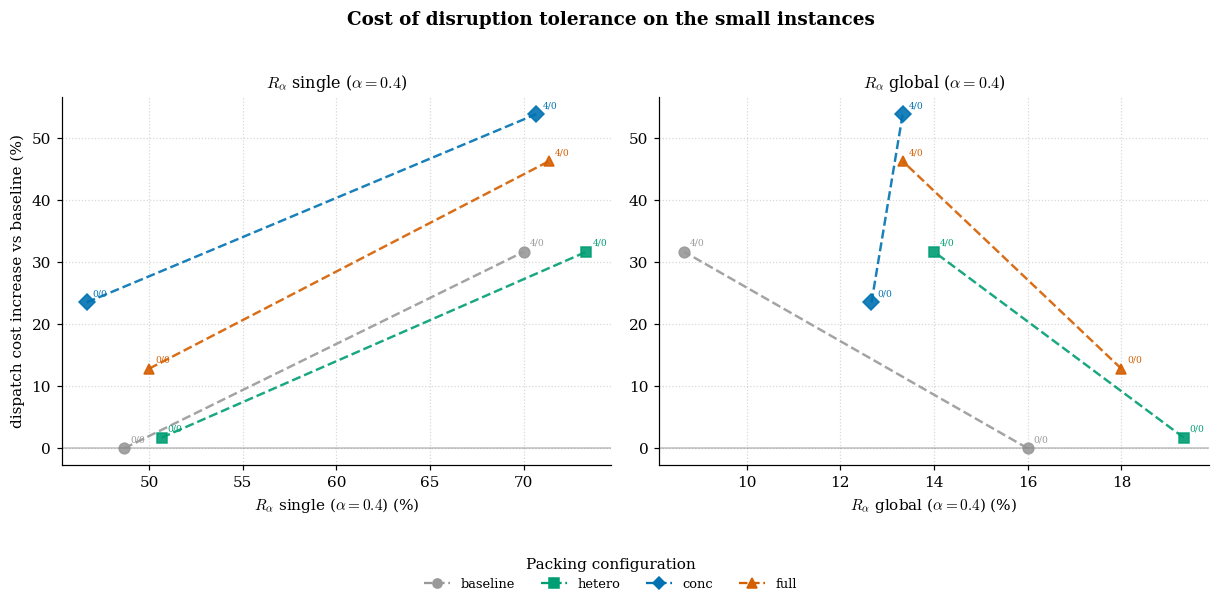

In [27]:

# alpha = 0.4 (larger packing spread); size_suite reused from the cell above
size_suite(DS, "small",
           [("r_alpha_single_0.4", r"$R_\alpha$ single ($\alpha{=}0.4$)"),
            ("r_alpha_global_0.4", r"$R_\alpha$ global ($\alpha{=}0.4$)")],
           "tradeoff_small_ralpha04")

**$R_\alpha$ packing profile (fixed flow)** — $R_\alpha$ vs $\alpha$ at the fixed cost-optimal flow, one line per packing config. With the flow fixed the network weight cannot act, so the packing ordering (hetero best, especially global scope) is visible.

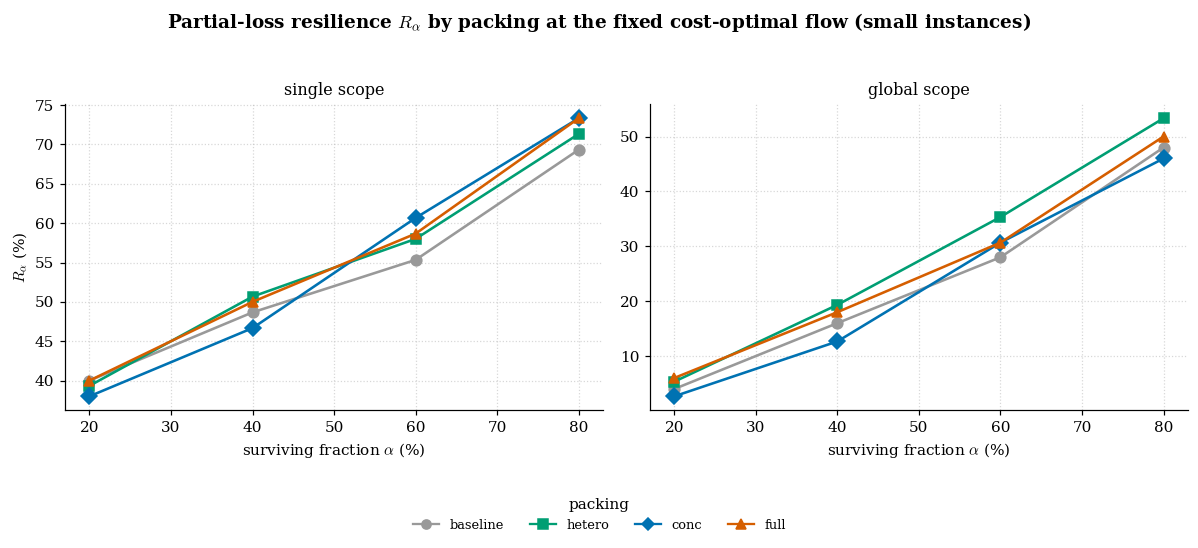

In [28]:
def ralpha_packing_profile(d, size, stem, alphas=(0.2, 0.4, 0.6, 0.8)):
    """Fixed cost-optimal flow (lambda_net = lambda_flow = 0): R_alpha against the surviving
    fraction alpha, one line per packing config. With the flow held fixed the network weight
    cannot act, so the packing ordering is visible directly. Single and global panels."""
    g0 = d[(d["size"] == size) & (d.lambda_net == 0) & (d.lambda_flow == 0)]
    xs = [a * 100 for a in alphas]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    for ax, mode in zip(axes, ["single", "global"]):
        for cfg in CFG_ORDER:
            gg = g0[g0.config == cfg]
            ys = [gg[f"r_alpha_{mode}_{a}"].mean() * 100 for a in alphas]
            ax.plot(xs, ys, MARKERS[cfg] + "-", lw=1.7, ms=7,
                    color=CFG_COLOR[cfg], label=CFG_LABEL[cfg])
        ax.set_title(f"{mode} scope")
        ax.set_xlabel(r"surviving fraction $\alpha$ (%)")
        ax.grid(True, ls=":", alpha=0.5)
    axes[0].set_ylabel(r"$R_\alpha$ (%)")
    handles = [Line2D([], [], marker=MARKERS[c], ls="-", color=CFG_COLOR[c],
                      label=CFG_LABEL[c]) for c in CFG_ORDER]
    fig.legend(handles=handles, title="packing", ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, 0.04))
    fig.suptitle(r"Partial-loss resilience $R_\alpha$ by packing at the fixed cost-optimal "
                 f"flow ({size} instances)", fontweight="bold")
    fig.tight_layout(rect=(0, 0.06, 1, 0.95))
    _save(fig, stem)

ralpha_packing_profile(DTD, "small", "ralpha_packing_profile_small")

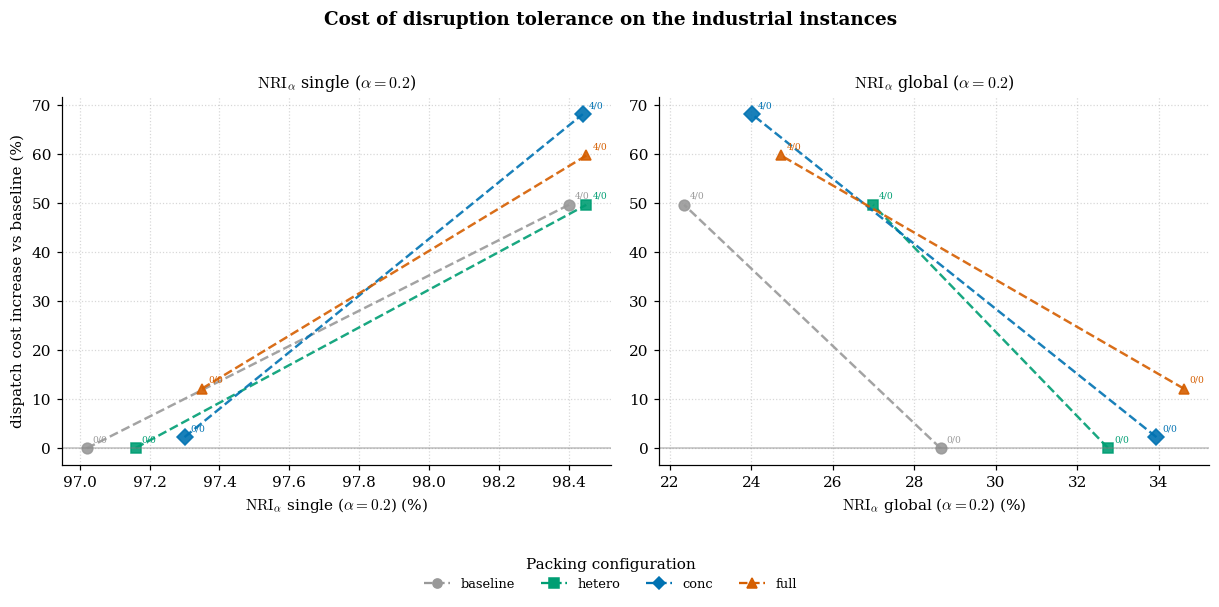

In [29]:
# nri_alpha (alpha=0.8), w_net lever only — reuses size_suite + _save from the cell above
size = "industrial"
DS = DTD[DTD.lambda_flow == 0]
size_suite(DS, size,
           [("nri_alpha_single_0.8", r"$\mathrm{NRI}_\alpha$ single ($\alpha{=}0.2$)"),
            ("nri_alpha_global_0.8", r"$\mathrm{NRI}_\alpha$ global ($\alpha{=}0.2$)")],
           f"tradeoff_{size}_nrialpha08")